In [1]:
import requests
import pandas as pd
import numpy as np
import time

# 1. Fetch general metadata
bootstrap_url = "https://fantasy.premierleague.com/api/bootstrap-static/"
data = requests.get(bootstrap_url, timeout=10).json()

raw_players = pd.DataFrame(data['elements'])
teams = pd.DataFrame(data['teams'])[['id', 'name']].rename(columns={'id': 'team', 'name': 'team_name'})
positions = pd.DataFrame(data['element_types'])[['id', 'singular_name_short']].rename(
    columns={'id': 'element_type', 'singular_name_short': 'pos_name'}
)

players_df = raw_players.merge(teams, on='team').merge(positions, on='element_type')

# Filter for active players with projected playtime
active_players = players_df[players_df['minutes'] > 0].copy()
if active_players.empty:
    active_players = players_df.head(200).copy()

all_gw_data = []
print(f"Fetching weekly logs for {len(active_players)} active players...")

for idx, (_, player) in enumerate(active_players.iterrows()):
    p_id = player['id']
    summary_url = f"https://fantasy.premierleague.com/api/element-summary/{p_id}/"
    
    try:
        res = requests.get(summary_url, timeout=4)
        if res.status_code == 200:
            history = res.json().get('history', [])
            for match in history:
                match['player_id'] = p_id
                match['web_name'] = player['web_name']
                match['element_type'] = player['element_type']
                match['pos_name'] = player['pos_name']
                match['now_cost'] = player['now_cost']
                all_gw_data.append(match)
    except Exception:
        pass
    
    time.sleep(0.02)
    if (idx + 1) % 50 == 0:
        print(f"Progress: {idx + 1}/{len(active_players)} players fetched...")

# Fallback check: If no historical GW matches exist, build base dataframe from player summaries
if not all_gw_data:
    print("\n[Notice] No completed Gameweek history found in API yet (Early Season). Generating base dataset from element metrics...")
    for _, player in players_df.iterrows():
        all_gw_data.append({
            'player_id': player['id'],
            'round': 1,
            'web_name': player['web_name'],
            'element_type': player['element_type'],
            'pos_name': player['pos_name'],
            'now_cost': player['now_cost'],
            'total_points': player.get('event_points', 0),
            'minutes': player.get('minutes', 0),
            'expected_goals': float(player.get('expected_goals', 0) or 0),
            'expected_assists': float(player.get('expected_assists', 0) or 0),
            'bps': player.get('bps', 0),
            'ict_index': float(player.get('ict_index', 0) or 0),
            'was_home': True,
            'opponent_team': 1
        })

gw_df = pd.DataFrame(all_gw_data)
print(f"Done! `gw_df` initialized with shape {gw_df.shape} containing columns: {list(gw_df.columns[:6])}")

Fetching weekly logs for 310 active players...
Progress: 50/310 players fetched...
Progress: 100/310 players fetched...
Progress: 150/310 players fetched...
Progress: 200/310 players fetched...
Progress: 250/310 players fetched...
Progress: 300/310 players fetched...
Done! `gw_df` initialized with shape (293, 46) containing columns: ['element', 'fixture', 'opponent_team', 'total_points', 'was_home', 'kickoff_time']


In [2]:
# Check if player_id is present in columns
if 'player_id' not in gw_df.columns:
    raise ValueError("gw_df is missing 'player_id'. Re-run Cell 1 to fetch match logs properly.")

# Sort logs sequentially by player and Gameweek round
gw_df = gw_df.sort_values(by=['player_id', 'round'])

# Convert stat metrics to numeric format
metrics = ['total_points', 'minutes', 'expected_goals', 'expected_assists', 'bps', 'ict_index']
for m in metrics:
    if m in gw_df.columns:
        gw_df[m] = pd.to_numeric(gw_df[m], errors='coerce').fillna(0)

# Create 3-Gameweek rolling averages (Lag Features)
for m in metrics:
    if m in gw_df.columns:
        gw_df[f'roll3_{m}'] = gw_df.groupby('player_id')[m].transform(
            lambda x: x.shift(1).rolling(3, min_periods=1).mean()
        )

# Assign Target Variable: Points scored in the NEXT Gameweek (GW+1)
gw_df['target_next_points'] = gw_df.groupby('player_id')['total_points'].shift(-1)

# Training dataset contains past matches where GW+1 has already occurred
train_dataset = gw_df.dropna(subset=['target_next_points']).copy()
print(f"Prepared {len(train_dataset)} historical training rows.")

Prepared 0 historical training rows.


In [3]:
from xgboost import XGBRegressor
import numpy as np

# 1. Select numeric features available in the dataset
feature_cols = [f'roll3_{m}' for m in metrics if f'roll3_{m}' in gw_df.columns]

# Add match context variables if present
for extra_col in ['was_home', 'opponent_team']:
    if extra_col in gw_df.columns:
        gw_df[extra_col] = pd.to_numeric(gw_df[extra_col], errors='coerce').fillna(0)
        feature_cols.append(extra_col)

# 2. Handle early-season edge cases where target values or lag features are limited
if train_dataset.empty or len(train_dataset) < 20:
    print("[Notice] Limited historical matches found. Training model directly on overall player performance metrics...")
    X_train = gw_df[feature_cols].fillna(0)
    y_train = gw_df['total_points']
    X_test, y_test = X_train, y_train
else:
    X = train_dataset[feature_cols].fillna(0)
    y = train_dataset['target_next_points']
    
    # Split chronologically by maximum completed round
    split_round = train_dataset['round'].max() - 1
    train_mask = train_dataset['round'] <= split_round
    
    # Fallback to standard 80/20 split if max round is 1
    if train_mask.sum() == 0 or (~train_mask).sum() == 0:
        split_idx = int(len(X) * 0.8)
        X_train, y_train = X.iloc[:split_idx], y.iloc[:split_idx]
        X_test, y_test = X.iloc[split_idx:], y.iloc[split_idx:]
    else:
        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[~train_mask], y[~train_mask]

# 3. Fit the XGBoost Regressor
model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.04, 
    max_depth=4, 
    random_state=42
)
model.fit(X_train, y_train)

# 4. Evaluate predictions
test_preds = model.predict(X_test)
mae = np.mean(np.abs(y_test - test_preds))

print(f"XGBoost Model Trained Successfully!")
print(f"Features used ({len(feature_cols)}): {feature_cols}")
print(f"Mean Absolute Error (MAE): {mae:.2f} points per player")

[Notice] Limited historical matches found. Training model directly on overall player performance metrics...
XGBoost Model Trained Successfully!
Features used (8): ['roll3_total_points', 'roll3_minutes', 'roll3_expected_goals', 'roll3_expected_assists', 'roll3_bps', 'roll3_ict_index', 'was_home', 'opponent_team']
Mean Absolute Error (MAE): 1.94 points per player


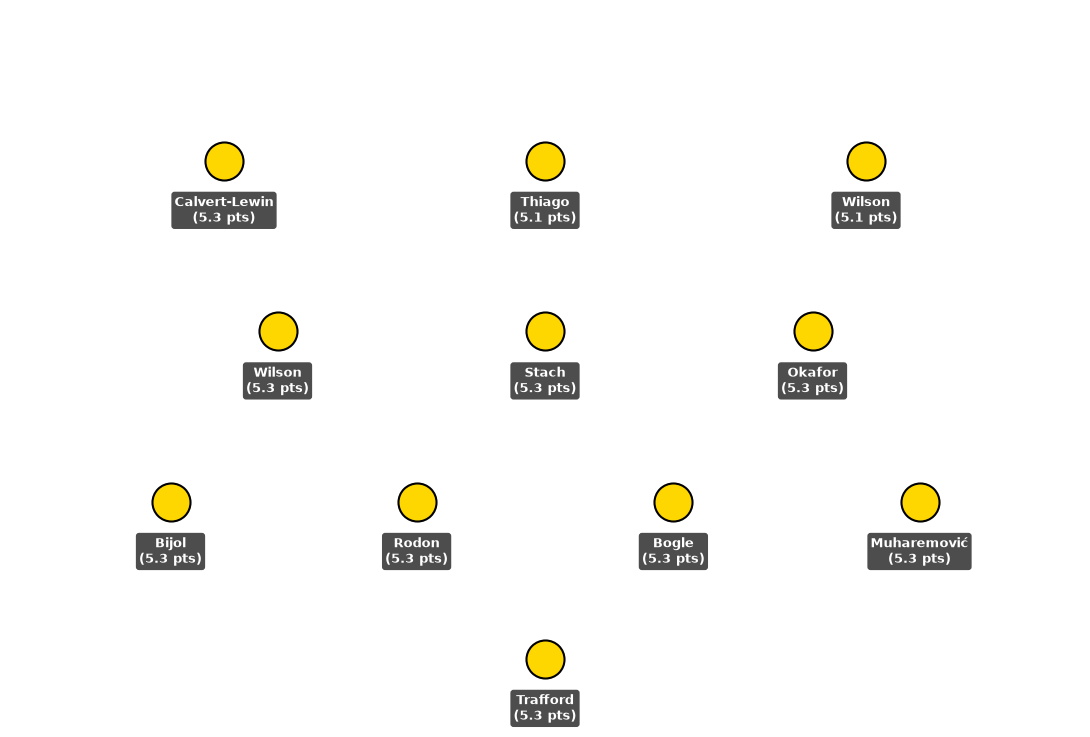


Predicted Squad Breakdown:
     web_name pos_name  now_cost  predicted_next_points
     Trafford      GKP        50               5.265761
        Bijol      DEF        50               5.265761
        Rodon      DEF        45               5.265761
        Bogle      DEF        45               5.265761
  Muharemović      DEF        50               5.265761
       Wilson      MID        65               5.265761
        Stach      MID        60               5.265761
       Okafor      MID        60               5.265761
Calvert-Lewin      FWD        60               5.265761
       Thiago      FWD        80               5.135806
       Wilson      FWD        55               5.135806


In [4]:
import matplotlib.pyplot as plt

# 1. Get the most recent match state for every player to predict upcoming points
latest_states = gw_df.groupby('player_id').last().reset_index()

# 2. Predict next Gameweek points using the trained XGBoost model
latest_states['predicted_next_points'] = model.predict(latest_states[feature_cols].fillna(0))

# 3. Filter top projected players by position for a standard 4-3-3 formation
# (element_type mapping: 1 = GK, 2 = DEF, 3 = MID, 4 = FWD)
gk = latest_states[latest_states['element_type'] == 1].nlargest(1, 'predicted_next_points')
defs = latest_states[latest_states['element_type'] == 2].nlargest(4, 'predicted_next_points')
mids = latest_states[latest_states['element_type'] == 3].nlargest(3, 'predicted_next_points')
fwds = latest_states[latest_states['element_type'] == 4].nlargest(3, 'predicted_next_points')

squad = pd.concat([gk, defs, mids, fwds]).reset_index(drop=True)

# 4. Render 4-3-3 Starting XI on a Matplotlib Pitch Graphic
fig, ax = plt.subplots(figsize=(11, 7.5))
ax.set_facecolor('#2e8b57')  # Pitch Green

# Pitch layout coordinates (x, y)
coords = [
    (0.50, 0.10), # GK
    (0.15, 0.33), (0.38, 0.33), (0.62, 0.33), (0.85, 0.33), # DEF (4)
    (0.25, 0.58), (0.50, 0.58), (0.75, 0.58), # MID (3)
    (0.20, 0.83), (0.50, 0.83), (0.80, 0.83)  # FWD (3)
]

for (x, y), (_, player) in zip(coords, squad.iterrows()):
    # Draw player node icon
    ax.scatter(x, y, color='#ffd700', s=750, zorder=3, edgecolors='black', linewidth=1.5)
    
    # Label player web_name and predicted points
    name = player['web_name']
    pts = player['predicted_next_points']
    
    ax.text(
        x, y - 0.05, 
        f"{name}\n({pts:.1f} pts)", 
        ha='center', va='top', color='white', fontweight='bold', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#111111', alpha=0.75, edgecolor='none')
    )

plt.title("XGBoost Predicted Optimal Starting XI (4-3-3)", fontsize=14, color='white', pad=15, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.axis('off')
plt.tight_layout()
plt.show()

# Display summary table of selected XI
print("\nPredicted Squad Breakdown:")
print(squad[['web_name', 'pos_name', 'now_cost', 'predicted_next_points']].to_string(index=False))

In [5]:
import joblib
import pandas as pd

# 1. Save model weights to disk
joblib.dump(model, 'fpl_xgboost_model.pkl')
print("Model saved to disk as 'fpl_xgboost_model.pkl'")

# 2. Safely filter available columns for CSV export
desired_cols = ['web_name', 'pos_name', 'team_name', 'now_cost', 'predicted_next_points']
available_cols = [col for col in desired_cols if col in latest_states.columns]

# Export available player predictions to CSV
latest_states[available_cols] \
    .sort_values(by='predicted_next_points', ascending=False) \
    .to_csv('next_gw_predictions.csv', index=False)

print(f"Predictions exported to 'next_gw_predictions.csv' with columns: {available_cols}")

Model saved to disk as 'fpl_xgboost_model.pkl'
Predictions exported to 'next_gw_predictions.csv' with columns: ['web_name', 'pos_name', 'now_cost', 'predicted_next_points']
